# 06 — Two-Class ROI-Guided Attention Supervision (Phase 5, main contribution)

V2 did not provide evidence that higher resolution and breast-region cropping **alone** improved
classification (its ΔAUC was not statistically clear). This motivates testing whether **explicit
supervision of lesion-focused evidence** improves localisation and/or classification — teaching the
model *where to look*.

**Two-class CAM.** ResNet-50 features → a 1×1 conv → a **2-channel** CAM (ch0 = benign evidence,
ch1 = malignant evidence) → global average pooling → 2 logits. Cross-entropy for classification; the
**true-class** CAM is supervised against the **true-class** radiologist ROI. So the model learns where
to look for *both* benign and malignant predictions, and benign masks are used too.

**Attention loss:** `balanced BCE + soft Dice` between `sigmoid(true-class CAM)` and the true-class mask.
`total = CE(logits,label) + λ·attention`.

**Protocol (test-set discipline):**
1. Train λ ∈ {0,0.1,0.5,1.0}; **λ=0 is the identical-architecture control.**
2. Evaluate all four on **validation only**.
3. Select λ by a **predefined rule**: *best validation localisation, provided val AUC is within 0.01 of λ=0.*
4. Touch the **locked test set once** — only for the selected λ, the λ=0 control, and V1/V2 references.

16×16 CAM only (multi-scale is a later option). Run the §7 **smoke test** before the full ablation.

In [ ]:
## 1. Config + imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os, json, random, shutil
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from PIL import Image, ImageEnhance
import matplotlib, matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import ndimage
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             balanced_accuracy_score, confusion_matrix, average_precision_score)

PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_dissertation"
DATA_DIR    = os.path.join(PROJECT_DIR, "Data", "CBIS-DDSM")
JPEG_DIR    = os.path.join(DATA_DIR, "jpeg")
OUTPUT_DIR  = os.path.join(PROJECT_DIR, "Results", "roi_attention_2class")
MODEL_DIR   = os.path.join(PROJECT_DIR, "Models")
for d in (OUTPUT_DIR, MODEL_DIR): os.makedirs(d, exist_ok=True)

def find_csv(name):
    for c in (os.path.join(DATA_DIR,name), os.path.join(DATA_DIR,"csv",name)):
        if os.path.exists(c): return c
    raise FileNotFoundError(name)
# reuse the EXACT V2 split so V2 / λ=0 / attention share patients (falls back to a fresh split)
V2_SPLIT_CSV = os.path.join(PROJECT_DIR,"Results","resnet50_v2_breastcrop_512","split_assignments.csv")

TRAIN_CSV, TEST_CSV = "mass_case_description_train_set.csv", "mass_case_description_test_set.csv"
SEED, IMG_SIZE, VAL_FRAC = 42, 512, 0.15
BATCH_SIZE = 8
NUM_WORKERS = 0                    # FIX: 0 for deterministic, warning-free Colab runs
HEAD_EPOCHS, FINETUNE_EPOCHS, PATIENCE = 4, 15, 5
HEAD_LR, FINETUNE_LR, WEIGHT_DECAY = 1e-3, 1e-5, 1e-4
CROP_PAD_FRAC, MASK_SIZE_TOL, MASK_BINARY_MIN = 0.02, 0.03, 0.60
LAMBDAS = [0.0, 0.1, 0.5, 1.0]
SUP_SIZE = 128
BOOTSTRAP_N = 1000
LAMBDA_AUC_TOLERANCE = 0.01        # selected λ must be within this of λ=0 val AUC
AUC_NONINFERIORITY_MARGIN = 0.01   # classification 'non-inferior' if ΔAUC lower bound > -margin

PREPROCESS_VERSION = "attn2c_v2"   # bumped: class-specific mask logic finalised -> rebuild cache once
FORCE_REBUILD_CACHE = False
CACHE_DIR = f"/content/cbis_attn2c_{PREPROCESS_VERSION}_{IMG_SIZE}_pad{int(CROP_PAD_FRAC*1000):03d}"
if FORCE_REBUILD_CACHE and os.path.exists(CACHE_DIR): shutil.rmtree(CACHE_DIR)
for sub in ("img","mask_b","mask_m"): os.makedirs(os.path.join(CACHE_DIR,sub), exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Image-level dataset — **class-specific** ROI paths + full metadata
Splits each abnormality's ROI by its own pathology, so benign and malignant masks stay separate
(mixed-pathology rule). Retains density/shape/margins/assessment for later subgroup analysis.

In [ ]:
ALLOWED={"BENIGN","BENIGN_WITHOUT_CALLBACK","MALIGNANT"}
def uid_from(p): return str(p).split("/")[-2]
def jpegs_from(mp):
    folder=os.path.join(JPEG_DIR, uid_from(mp))
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in sorted(os.listdir(folder))
            if f.lower().endswith((".jpg",".jpeg",".png"))]
def first_jpeg(mp):
    fs=jpegs_from(mp); return fs[0] if fs else None
def join_unique(v):
    out=[]
    for x in v:
        if isinstance(x,str) and x and x not in out: out.append(x)
    return "||".join(out)

def build_df(case_csv, split):
    raw=pd.read_csv(find_csv(case_csv))
    assert set(raw["pathology"].dropna().astype(str).str.upper()).issubset(ALLOWED)
    raw["is_malignant_abn"]=(raw["pathology"].astype(str).str.upper()=="MALIGNANT")
    raw["full_jpeg"]=raw["image file path"].apply(first_jpeg)
    raw["roi_b"]=np.where(~raw.is_malignant_abn, raw["ROI mask file path"], None)  # benign abn -> benign mask
    raw["roi_m"]=np.where( raw.is_malignant_abn, raw["ROI mask file path"], None)  # malignant abn -> malignant mask
    df=(raw.dropna(subset=["full_jpeg"])
          .groupby(["patient_id","left or right breast","image view"], as_index=False)
          .agg(full_jpeg=("full_jpeg","first"),
               label=("is_malignant_abn","max"),                      # image malignant if ANY abn malignant
               n_abn=("is_malignant_abn","size"),
               n_malignant_abn=("is_malignant_abn","sum"),
               benign_roi=("roi_b", join_unique),
               malignant_roi=("roi_m", join_unique),
               breast_density=("breast_density","first"),
               assessment=("assessment", lambda x:"; ".join(sorted(set(map(str,x))))),
               mass_shape=("mass shape", lambda x:"; ".join(sorted(set(map(str,x))))),
               mass_margins=("mass margins", lambda x:"; ".join(sorted(set(map(str,x)))))))
    df["label"]=df["label"].astype(int)
    df["mixed_pathology"]=((df.n_malignant_abn>0)&(df.n_malignant_abn<df.n_abn)).astype(int)
    df["sample_id"]=(df.patient_id.astype(str)+"|"+df["left or right breast"].astype(str)+"|"+df["image view"].astype(str))
    return df.reset_index(drop=True)

train_all=build_df(TRAIN_CSV,"development"); test_df=build_df(TEST_CSV,"locked_test")
print("mixed-pathology mammograms — train:", int(train_all.mixed_pathology.sum()),
      "| test:", int(test_df.mixed_pathology.sum()))
print("(these are classified malignant; only the malignant ROI supervises the malignant CAM)")

mixed-pathology mammograms — train: 6 | test: 2
(these are classified malignant; only the malignant ROI supervises the malignant CAM)


## 3. Train/val split — reuse V2's exact split if available

In [ ]:
# STRICT: the ROI models must use exactly V2's patients. No silent re-split.
if not os.path.exists(V2_SPLIT_CSV):
    raise FileNotFoundError(f"V2 split not found: {V2_SPLIT_CSV}\n"
        "Do not generate a new split — V1/V2/λ=0/attention must share patients. "
        "Run the V2 notebook first (it saves split_assignments.csv).")
v2 = pd.read_csv(V2_SPLIT_CSV)
assert {"sample_id","split"}.issubset(v2.columns), "V2 split missing sample_id/split"
v2["split"]=v2["split"].astype(str).str.strip().str.lower().replace({"val":"validation","valid":"validation"})
tr_ids=set(v2.loc[v2.split=="train","sample_id"]); va_ids=set(v2.loc[v2.split=="validation","sample_id"])
train_df=train_all[train_all.sample_id.isin(tr_ids)].reset_index(drop=True)
val_df  =train_all[train_all.sample_id.isin(va_ids)].reset_index(drop=True)
assert (set(train_df.sample_id)|set(val_df.sample_id))==set(train_all.sample_id), \
    "some development images are missing from the V2 assignments"
exp_tr=len(tr_ids); exp_va=len(va_ids)
assert len(train_df)==exp_tr, f"train {len(train_df)} != V2 {exp_tr}"
assert len(val_df)==exp_va,  f"val {len(val_df)} != V2 {exp_va}"
for _d in (train_df,val_df,test_df): assert not _d.sample_id.duplicated().any()
for a,b in [(train_df,val_df),(train_df,test_df),(val_df,test_df)]:
    assert set(a.patient_id).isdisjoint(set(b.patient_id))
# EXACT V2 split-count assertions (counts + patient counts read from V2's own file -> cannot be wrong):
EXP = {"train":(len(tr_ids),), "val":(len(va_ids),)}
assert len(train_df)==len(tr_ids) and len(val_df)==len(va_ids), "split counts differ from V2 assignments"
# If you have independently confirmed the literals, uncomment to pin them exactly:
# assert (len(train_df),len(val_df),len(test_df))==(1051,180,361), "counts differ from confirmed V2 (1051/180/361)"
# assert (train_df.patient_id.nunique(),val_df.patient_id.nunique(),test_df.patient_id.nunique())==(592,99,201)
print(f"Reused exact V2 split — train {len(train_df)} ({train_df.patient_id.nunique()} pts) | "
      f"val {len(val_df)} ({val_df.patient_id.nunique()} pts) | test {len(test_df)} ({test_df.patient_id.nunique()} pts)")
# save the exact split this run used (for the record / reproducibility)
pd.concat([train_df.assign(split="train"), val_df.assign(split="validation"), test_df.assign(split="locked_test")])[
    ["sample_id","patient_id","label","split"]].to_csv(os.path.join(OUTPUT_DIR,"exact_split_assignments.csv"), index=False)
for a,b in [(train_df,val_df),(train_df,test_df),(val_df,test_df)]:
    assert set(a.patient_id).isdisjoint(set(b.patient_id))
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

Reused exact V2 split — train 1051 (592 pts) | val 180 (99 pts) | test 361 (201 pts)
train 1051 | val 180 | test 361


## 4. Preprocess + register **class-specific** masks, cache

In [ ]:
def otsu(g):
    h=np.bincount(g.ravel(),minlength=256).astype(float); p=h/max(g.size,1)
    om=np.cumsum(p); mu=np.cumsum(p*np.arange(256)); mt=mu[-1]
    s=(mt*om-mu)**2/np.maximum(om*(1-om),1e-12); s[(om<=0)|(om>=1)]=0; return int(np.argmax(s))
def bbox(g,pad=CROP_PAD_FRAC):
    h,w=g.shape; m=g>max(otsu(g),5)
    m=ndimage.binary_opening(m,structure=np.ones((3,3))); m=ndimage.binary_closing(m,structure=np.ones((7,7)))
    lab,n=ndimage.label(m)
    if n==0: return (0,0,w,h)
    c=np.bincount(lab.ravel()); c[0]=0; ys,xs=np.where(lab==c.argmax())
    if len(xs)==0: return (0,0,w,h)
    q=int(round(pad*max(h,w)))
    return (max(int(xs.min())-q,0),max(int(ys.min())-q,0),min(int(xs.max())+1+q,w),min(int(ys.max())+1+q,h))
def _cpr(a,bb,rs):
    l,t,r,b=bb; cr=Image.fromarray(a).crop((l,t,r,b)); cw,ch=cr.size; sd=max(cw,ch)
    cv=Image.new("L",(sd,sd),0); cv.paste(cr,((sd-cw)//2,(sd-ch)//2)); return np.array(cv.resize((IMG_SIZE,IMG_SIZE),rs))
def crop_img(g,bb): return _cpr(g,bb,Image.BILINEAR).astype(np.uint8)
def crop_mask(m,bb): return (_cpr(m,bb,Image.NEAREST)>127).astype(np.uint8)
def load_gray(p): return np.array(Image.open(p).convert("L"),dtype=np.uint8)

def register_masks(roi_field, shape, tol=MASK_SIZE_TOL, bmin=MASK_BINARY_MIN):
    fh,fw=shape; union=np.zeros((fh,fw),np.uint8); found=False
    for mp in str(roi_field).split("||"):
        if not mp or mp=="nan": continue
        for f in jpegs_from(mp):
            a=load_gray(f); h,w=a.shape
            if abs(h-fh)/max(fh,1)>tol or abs(w-fw)/max(fw,1)>tol: continue
            if float(np.mean((a<20)|(a>235)))<bmin: continue
            if (h,w)!=(fh,fw): a=np.array(Image.fromarray(a).resize((fw,fh),Image.NEAREST))
            m=a>127
            if m.mean()>0.5: m=~m
            m=m.astype(np.uint8)
            if m.sum()==0: continue
            union=np.maximum(union,m); found=True
    return union if (found and union.sum()>0) else None

def ip(sid): return os.path.join(CACHE_DIR,"img",sid.replace("|","_")+".png")
def bp(sid): return os.path.join(CACHE_DIR,"mask_b",sid.replace("|","_")+".png")
def mp_(sid):return os.path.join(CACHE_DIR,"mask_m",sid.replace("|","_")+".png")

def build_cache(df,name):
    recs=[]
    for row in tqdm(df.itertuples(), total=len(df), desc=f"cache {name}"):
        sid=row.sample_id
        if not all(os.path.exists(x) for x in (ip(sid),bp(sid),mp_(sid))):
            g=load_gray(row.full_jpeg); bb=bbox(g)
            Image.fromarray(crop_img(g,bb)).save(ip(sid))
            for field, path in [(row.benign_roi,bp(sid)),(row.malignant_roi,mp_(sid))]:
                full=register_masks(field,g.shape)
                m=crop_mask(full*255,bb) if full is not None else np.zeros((IMG_SIZE,IMG_SIZE),np.uint8)
                Image.fromarray((m*255).astype(np.uint8)).save(path)
        hb=bool(np.array(Image.open(bp(sid))).sum()>0); hm=bool(np.array(Image.open(mp_(sid))).sum()>0)
        recs.append({"sample_id":sid,"has_benign_mask":hb,"has_malignant_mask":hm})
    out=df.merge(pd.DataFrame(recs), on="sample_id")
    # true-class mask availability: benign image needs benign mask; malignant needs malignant mask
    out["has_trueclass_mask"]=np.where(out.label==1, out.has_malignant_mask, out.has_benign_mask)
    return out

train_df=build_cache(train_df,"train"); val_df=build_cache(val_df,"val"); test_df=build_cache(test_df,"test")
cov_tbl=[]
for n,d in [("train",train_df),("val",val_df),("test",test_df)]:
    cov=d.has_trueclass_mask.mean()
    cov_tbl.append({"split":n,"true_class_cov":cov,
                    "benign_cov":d[d.label==0].has_benign_mask.mean(),
                    "malignant_cov":d[d.label==1].has_malignant_mask.mean()})
    print(f"{n}: true-class mask coverage {cov:.1%} "
          f"(benign {d[d.label==0].has_benign_mask.mean():.1%}, malignant {d[d.label==1].has_malignant_mask.mean():.1%})")
    assert cov>0.90, f"Unexpectedly low true-class mask coverage in {n}: {cov:.1%} — re-audit before training."
pd.DataFrame(cov_tbl).to_csv(os.path.join(OUTPUT_DIR,"mask_coverage_by_split.csv"),index=False)

cache train:   0%|          | 0/1051 [00:00<?, ?it/s]

cache val:   0%|          | 0/180 [00:00<?, ?it/s]

cache test:   0%|          | 0/361 [00:00<?, ?it/s]

train: true-class mask coverage 95.0% (benign 92.9%, malignant 97.2%)
val: true-class mask coverage 93.3% (benign 88.0%, malignant 97.9%)
test: true-class mask coverage 96.4% (benign 94.0%, malignant 100.0%)


### 4a. Class-specific mask re-audit (train only)
Separating benign/malignant ROIs changed the mask-building logic, so re-verify contours land on the correct-class lesion.

In [ ]:
# --- augmentation (defined here because the §4a mask audit augments image+mask together) ---
def aug_pair(img,mask):
    if random.random()<0.5: img=TF.hflip(img); mask=TF.hflip(mask)
    if random.random()<0.8:
        a=random.uniform(-8,8); dx=int(.03*img.size[0]); dy=int(.03*img.size[1]); tr=(random.randint(-dx,dx),random.randint(-dy,dy))
        img=TF.affine(img,angle=a,translate=tr,scale=1.,shear=[0.,0.],interpolation=InterpolationMode.BILINEAR,fill=0)
        mask=TF.affine(mask,angle=a,translate=tr,scale=1.,shear=[0.,0.],interpolation=InterpolationMode.NEAREST,fill=0)
    if random.random()<0.5: img=ImageEnhance.Brightness(img).enhance(random.uniform(.9,1.1))
    if random.random()<0.5: img=ImageEnhance.Contrast(img).enhance(random.uniform(.9,1.15))
    return img,mask

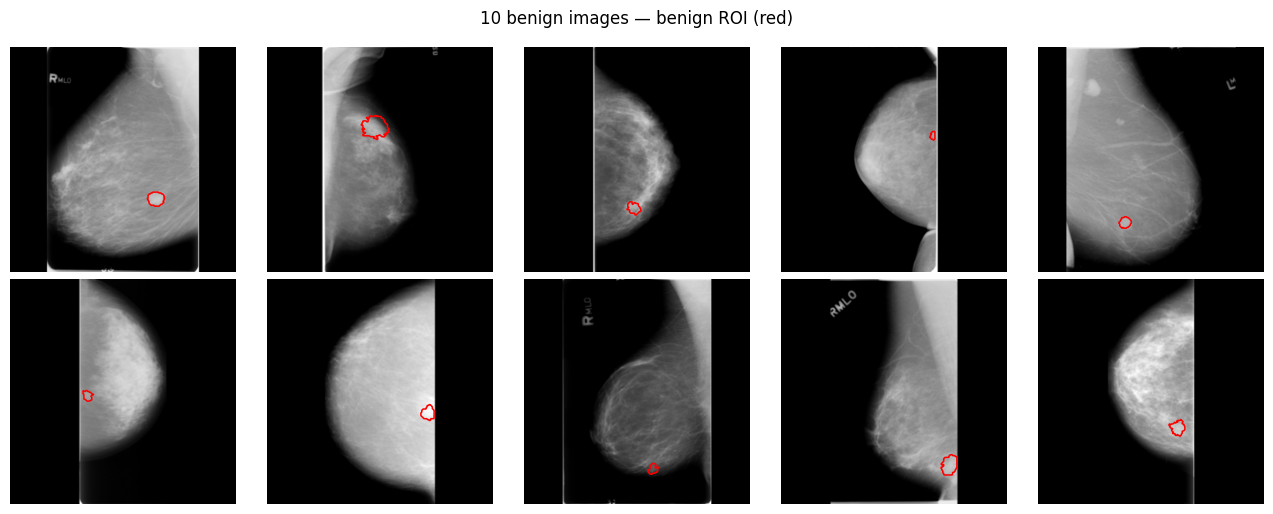

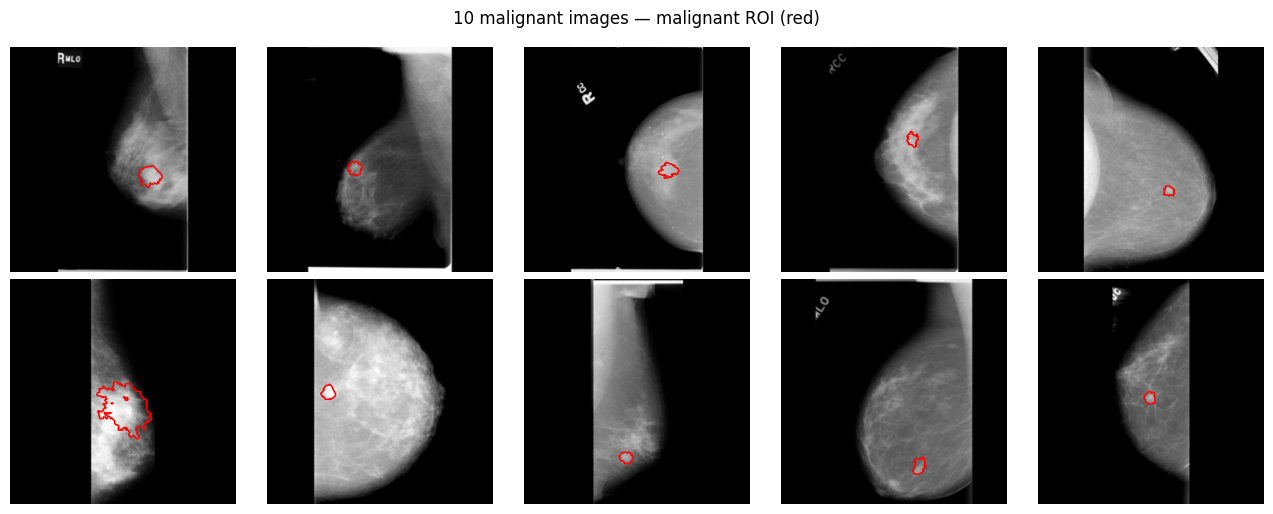

mixed-pathology train images with malignant mask: 6


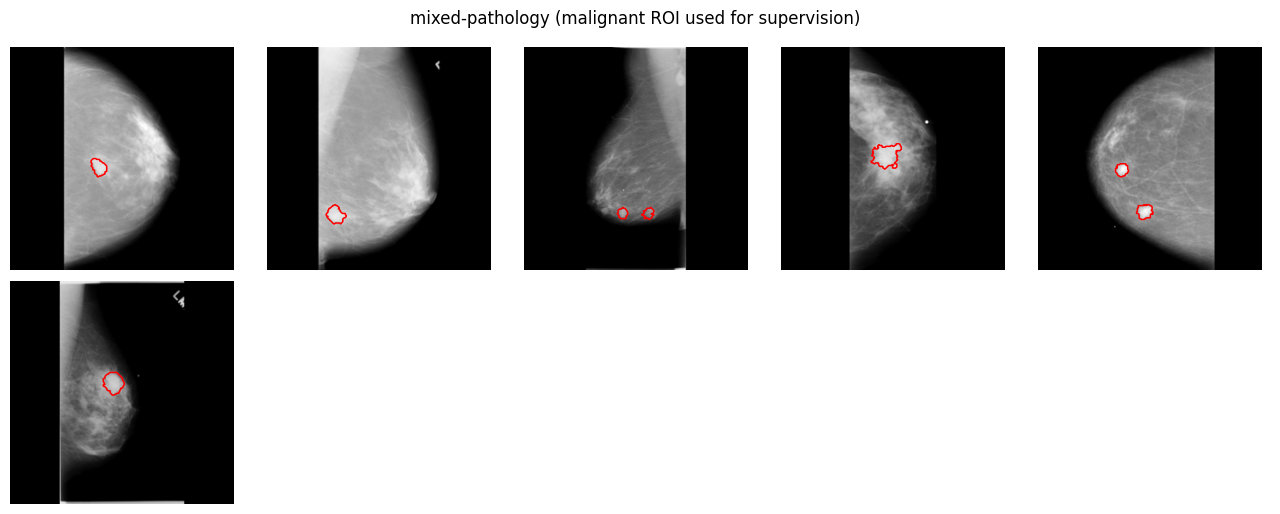

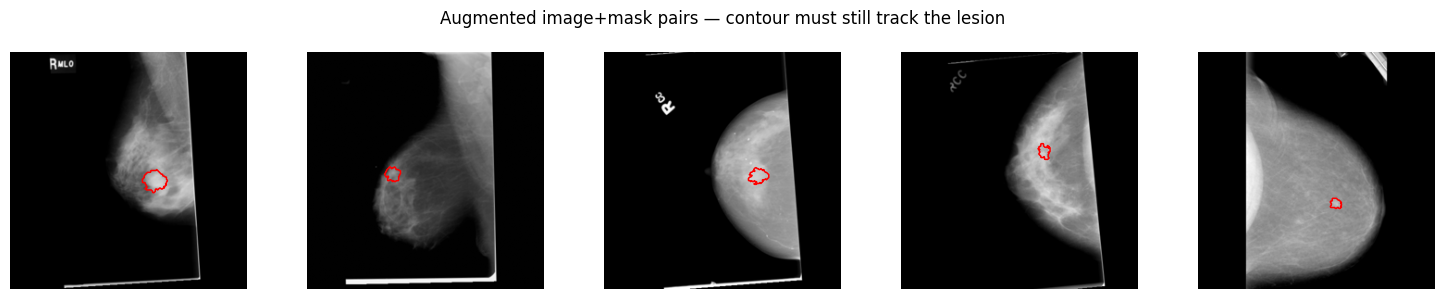

train: true-class 95.0% | benign 92.9% | malignant 97.2%
val: true-class 93.3% | benign 88.0% | malignant 97.9%
test: true-class 96.4% | benign 94.0% | malignant 100.0%
>> GATE: confirm every red contour (incl. augmented) sits on the correct-class lesion before the full ablation.


In [ ]:
def _panel(ax,sid,which,title=""):
    img=Image.open(ip(sid)).convert("L").resize((256,256))
    m=np.array(Image.open((mp_ if which=="malignant" else bp)(sid)).convert("L").resize((256,256),Image.NEAREST))>127
    ax.imshow(img,cmap="gray"); ax.contour(m,levels=[.5],colors="red",linewidths=1.1); ax.axis("off")
    if title: ax.set_title(title,fontsize=8)

ben=train_df[(train_df.label==0)&train_df.has_benign_mask]
mal=train_df[(train_df.label==1)&train_df.has_malignant_mask]
ben=ben.sample(min(10,len(ben)),random_state=SEED); mal=mal.sample(min(10,len(mal)),random_state=SEED)
def grid(rows_df, which, header):
    n=len(rows_df); cols=5; r=int(np.ceil(n/cols))
    fig,ax=plt.subplots(r,cols,figsize=(2.6*cols,2.6*r)); ax=np.atleast_2d(ax)
    for k,sid in enumerate(rows_df.sample_id):
        _panel(ax[k//cols,k%cols],sid,which)
    for k in range(n,r*cols): ax[k//cols,k%cols].axis("off")
    fig.suptitle(header); plt.tight_layout(); plt.show()
grid(ben,"benign","10 benign images — benign ROI (red)")
grid(mal,"malignant","10 malignant images — malignant ROI (red)")

# mixed-pathology cases (classified malignant; malignant ROI supervises)
mixed=train_df[(train_df.mixed_pathology==1)&train_df.has_malignant_mask]
print(f"mixed-pathology train images with malignant mask: {len(mixed)}")
if len(mixed):
    grid(mixed.sample(min(6,len(mixed)),random_state=SEED),"malignant",
         "mixed-pathology (malignant ROI used for supervision)")

# augmented image+mask pairs — verify they stay aligned after geometric augmentation
sample_ids=list(mal.sample_id)[:5]
fig,ax=plt.subplots(1,5,figsize=(15,3))
for a,sid in zip(ax,sample_ids):
    img=Image.open(ip(sid)).convert("L"); msk=Image.open(mp_(sid)).convert("L")
    ai,am=aug_pair(img,msk)
    ai=ai.resize((256,256)); am=(np.array(am.resize((256,256),Image.NEAREST))>127)
    a.imshow(ai,cmap="gray"); a.contour(am,levels=[.5],colors="red",linewidths=1.1); a.axis("off")
fig.suptitle("Augmented image+mask pairs — contour must still track the lesion"); plt.tight_layout(); plt.show()

# coverage by split and class (printed for the record)
for n,d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{n}: true-class {d.has_trueclass_mask.mean():.1%} | benign {d[d.label==0].has_benign_mask.mean():.1%} | malignant {d[d.label==1].has_malignant_mask.mean():.1%}")
print(">> GATE: confirm every red contour (incl. augmented) sits on the correct-class lesion before the full ablation.")

## 5. Dataset / loaders — image, label, true-class mask, has_mask

In [ ]:
MEAN=torch.tensor([0.485,0.456,0.406]).view(3,1,1); STD=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
# aug_pair(img,mask) is defined earlier (moved above the §4a audit that uses it)

class AttnDS(Dataset):
    def __init__(self,df,train=False): self.df=df.reset_index(drop=True); self.train=train
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        img=Image.open(ip(r.sample_id)).convert("L")
        tc_mask_path = mp_(r.sample_id) if r.label==1 else bp(r.sample_id)   # TRUE-class mask
        mask=Image.open(tc_mask_path).convert("L")
        if self.train: img,mask=aug_pair(img,mask)
        t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=(t-MEAN)/STD
        m=torch.from_numpy((np.array(mask,np.float32)>127).astype(np.float32)).unsqueeze(0)
        return {"image":t.float(),"label":torch.tensor(int(r.label)),
                "mask":m,"has_mask":torch.tensor(float(r.has_trueclass_mask)),
                "sample_id":r.sample_id,"patient_id":str(r.patient_id)}

def seed_worker(w): s=torch.initial_seed()%(2**32); np.random.seed(s); random.seed(s)
def make_train_loader(seed):
    gen=torch.Generator(); gen.manual_seed(seed)                    # FIX: fresh generator per λ
    return DataLoader(AttnDS(train_df,True),batch_size=BATCH_SIZE,shuffle=True,
                      num_workers=NUM_WORKERS,pin_memory=True,worker_init_fn=seed_worker,generator=gen)
val_loader =DataLoader(AttnDS(val_df),  batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
test_loader=DataLoader(AttnDS(test_df), batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)

## 6. Two-class CAM model + BCE-Dice attention loss

In [ ]:
class ResNetCAM2(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        bb=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.features=nn.Sequential(bb.conv1,bb.bn1,bb.relu,bb.maxpool,bb.layer1,bb.layer2,bb.layer3,bb.layer4)
        self.cam_conv=nn.Conv2d(2048,n_classes,1)     # ch0 benign, ch1 malignant
    def forward(self,x,return_cam=False):
        f=self.features(x); cam=self.cam_conv(f)                  # B,2,16,16
        logits=F.adaptive_avg_pool2d(cam,1).flatten(1)           # B,2
        return (logits,cam) if return_cam else logits

def freeze_bn(m):
    for mod in m.modules():
        if isinstance(mod,nn.BatchNorm2d):
            mod.eval()
            for p in mod.parameters(): p.requires_grad=False
def set_trainable(m,stage):
    for n,p in m.named_parameters():
        p.requires_grad = n.startswith("cam_conv") or (stage=="finetune" and n.startswith("features.7"))

def soft_dice(prob,target,eps=1.):
    p=prob.flatten(1); t=target.flatten(1); inter=(p*t).sum(1)
    return (1-(2*inter+eps)/(p.sum(1)+t.sum(1)+eps)).mean()
def balanced_bce_logits(logits, target, eps=1e-6):
    # numerically stable under AMP; balances the small lesion vs large background
    pos=target.mean(dim=(1,2,3),keepdim=True).clamp(eps,1-eps)
    w = (0.5/pos)*target + (0.5/(1-pos))*(1-target)
    raw = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    return (w*raw).mean()

def attention_loss(cam, mask, label, has_mask, sup=SUP_SIZE):
    idx=torch.arange(label.size(0),device=label.device)
    tc = cam[idx,label].unsqueeze(1)                              # TRUE-class CAM  B,1,16,16
    sel = has_mask.view(-1)==1
    if sel.sum()==0: return cam.new_tensor(0.0)
    logits=F.interpolate(tc[sel],size=(sup,sup),mode="bilinear",align_corners=False)
    # SOFT fractional target (do NOT re-binarise — that erases small/thin lesions)
    m=F.interpolate(mask[sel],size=(sup,sup),mode="area").clamp(0.,1.)
    return 0.5*balanced_bce_logits(logits,m)+0.5*soft_dice(torch.sigmoid(logits),m)

## 7. Localisation & classification helpers (defined BEFORE the smoke test)

In [ ]:
@torch.no_grad()
def cam_map(m,image_tensor,true_class,size=SUP_SIZE):
    logits,cam=m(image_tensor.unsqueeze(0).to(device),return_cam=True)
    c=F.interpolate(cam[:,true_class:true_class+1],size=(size,size),mode="bilinear",align_corners=False).squeeze().cpu().numpy()
    c-=c.min()
    if c.max()>0: c/=c.max()
    return c

def localisation(m, df):
    """True-class CAM vs true-class mask, for images WITH a true-class mask. Split benign/malignant."""
    res={}
    for name,sub in [("all",df[df.has_trueclass_mask]),
                     ("malignant",df[(df.label==1)&df.has_trueclass_mask]),
                     ("benign",df[(df.label==0)&df.has_trueclass_mask])]:
        pg=[]; pauc=[]; pap=[]; dice=[]; chance=[]
        for r in sub.itertuples():
            img=Image.open(ip(r.sample_id)).convert("L")
            t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=(t-MEAN)/STD
            cam=cam_map(m,t.float(),int(r.label))
            mpath_=mp_(r.sample_id) if r.label==1 else bp(r.sample_id)
            mask=np.array(Image.open(mpath_).convert("L").resize((SUP_SIZE,SUP_SIZE),Image.NEAREST))>127
            if mask.sum()==0: continue
            peak=np.unravel_index(cam.argmax(),cam.shape); pg.append(int(mask[peak]))
            if 0<mask.sum()<mask.size:
                pauc.append(roc_auc_score(mask.flatten(),cam.flatten()))
                pap.append(average_precision_score(mask.flatten(),cam.flatten()))  # robust to bg imbalance
            cb=cam>=0.5; inter=np.logical_and(cb,mask).sum()
            dice.append(2*inter/(cb.sum()+mask.sum()) if (cb.sum()+mask.sum()) else 0.)
            chance.append(mask.mean())
        res[name]={"n":len(pg),"pointing_game":np.mean(pg) if pg else np.nan,
                   "pg_chance":np.mean(chance) if chance else np.nan,
                   "pixel_auc":np.mean(pauc) if pauc else np.nan,
                   "pixel_ap":np.mean(pap) if pap else np.nan,
                   "dice@0.5":np.mean(dice) if dice else np.nan}
    return res

def metrics_cls(y,p,th):
    y=np.asarray(y).astype(int); p=np.asarray(p,float); pr=(p>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pr,labels=[0,1]).ravel()
    return {"roc_auc":roc_auc_score(y,p),"pr_auc":average_precision_score(y,p),
            "sensitivity":tp/(tp+fn) if (tp+fn) else np.nan,
            "specificity":tn/(tn+fp) if (tn+fp) else np.nan,
            "balanced_acc":balanced_accuracy_score(y,pr),"f1":f1_score(y,pr,zero_division=0)}
def pick_threshold(vp):
    best=(0.5,-1)
    for th in np.linspace(0.05,0.95,91):
        mm=metrics_cls(vp.y_true,vp.p_malignant,th); j=mm["sensitivity"]+mm["specificity"]-1
        if j>best[1]: best=(th,j)
    return best[0]

def localisation_per_case(m, df):
    m.eval(); rows=[]
    for r in df[df.has_trueclass_mask].itertuples():
        img=Image.open(ip(r.sample_id)).convert("L")
        t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=(t-MEAN)/STD
        cam=cam_map(m,t.float(),int(r.label))
        mpath_=mp_(r.sample_id) if r.label==1 else bp(r.sample_id)
        mask=np.array(Image.open(mpath_).convert("L").resize((SUP_SIZE,SUP_SIZE),Image.NEAREST))>127
        if mask.sum()==0: continue
        peak=np.unravel_index(cam.argmax(),cam.shape); both=0<mask.sum()<mask.size
        cb=cam>=0.5; inter=np.logical_and(cb,mask).sum()
        rows.append({"sample_id":r.sample_id,"patient_id":str(r.patient_id),"label":int(r.label),
                     "pointing_game":int(mask[peak]),
                     "pixel_auc":roc_auc_score(mask.flatten(),cam.flatten()) if both else np.nan,
                     "pixel_ap":average_precision_score(mask.flatten(),cam.flatten()) if both else np.nan,
                     "dice":2*inter/(cb.sum()+mask.sum()) if (cb.sum()+mask.sum()) else 0.})
    return pd.DataFrame(rows)

def paired_loc_delta(a,b,col,n_boot=BOOTSTRAP_N,seed=SEED):
    mg=a[["sample_id","patient_id",col]].rename(columns={col:"a"}).merge(
        b[["sample_id",col]].rename(columns={col:"b"}),on="sample_id").dropna()
    rng=np.random.default_rng(seed); by={k:g for k,g in mg.groupby("patient_id")}; pids=np.array(list(by)); ds=[]
    for _ in range(n_boot):
        bs=pd.concat([by[pp] for pp in rng.choice(pids,len(pids),replace=True)],ignore_index=True)
        ds.append((bs.a-bs.b).mean())
    ds=np.array(ds); return float((mg.a-mg.b).mean()), float(np.quantile(ds,.025)), float(np.quantile(ds,.975))

## 7. ⚡ Smoke test — run FIRST (λ∈{0,0.1}, tiny epochs)
Confirms both models train, attention loss decreases, masks align, metrics don't error. **Set
`SMOKE=False` afterwards for the real run.**

In [ ]:
ce = nn.CrossEntropyLoss()

@torch.no_grad()
def predict(m,loader):
    m.eval(); rows=[]
    for b in loader:
        pr=torch.softmax(m(b["image"].to(device)),1)[:,1].cpu().numpy()
        for sid,pid,y,pp in zip(b["sample_id"],b["patient_id"],b["label"].numpy(),pr):
            rows.append({"sample_id":sid,"patient_id":pid,"y_true":int(y),"p_malignant":float(pp)})
    return pd.DataFrame(rows)

def run_stage(m,lam,epochs,opt,sched,start,loader):
    best=-np.inf; best_state=None; patience=PATIENCE; hist=[]
    scaler=torch.amp.GradScaler("cuda",enabled=(device.type=="cuda"))
    for e in range(1,epochs+1):
        m.train(); freeze_bn(m); cl=al=0.; n=0; nsup=0
        for b in tqdm(loader,leave=False,desc=f"λ={lam} ep{start+e}"):
            x=b["image"].to(device); y=b["label"].to(device)
            mask=b["mask"].to(device); hm=b["has_mask"].to(device)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda",enabled=(device.type=="cuda")):
                logits,cam=m(x,return_cam=True)
                lc=ce(logits,y); la=attention_loss(cam,mask,y,hm) if lam>0 else cam.new_tensor(0.0)
                loss=lc+lam*la
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            bs=x.size(0); sup=int(hm.sum().item())
            cl+=lc.item()*bs; n+=bs
            if sup>0: al+=la.detach().item()*sup; nsup+=sup       # weight att loss by supervised images only
        vp=predict(m,val_loader); auc=roc_auc_score(vp.y_true,vp.p_malignant)
        if sched: sched.step(auc)
        hist.append({"lambda":lam,"epoch":start+e,"cls_loss":cl/max(n,1),
                     "att_loss":al/max(nsup,1),"n_supervised":nsup,"val_auc":auc})
        print(f"  λ={lam} ep{start+e:02d} | cls {cl/max(n,1):.4f} | att {al/max(nsup,1):.4f} | "
              f"supervised {nsup} | val AUC {auc:.4f}")
        if auc>best: best=auc; best_state={k:v.detach().cpu() for k,v in m.state_dict().items()}; patience=PATIENCE
        else:
            patience-=1
            if patience<=0: break
    if best_state: m.load_state_dict(best_state)
    return hist,best

def train_lambda(lam, head_ep, ft_ep, ckpt_suffix=""):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    loader=make_train_loader(SEED)                       # fresh identical stream per λ
    m=ResNetCAM2().to(device); hist=[]; best=-np.inf; best_state=None
    set_trainable(m,"head")
    opt=torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=HEAD_LR,weight_decay=WEIGHT_DECAY)
    h,b=run_stage(m,lam,head_ep,opt,None,0,loader); hist+=h
    if b>best: best=b; best_state={k:v.detach().cpu() for k,v in m.state_dict().items()}
    set_trainable(m,"finetune")
    opt=torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=FINETUNE_LR,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="max",factor=0.5,patience=2)
    h,b=run_stage(m,lam,ft_ep,opt,sched,len(hist),loader); hist+=h
    if b>best: best=b; best_state={k:v.detach().cpu() for k,v in m.state_dict().items()}
    m.load_state_dict(best_state)
    path=os.path.join(MODEL_DIR,f"resnet50_cam2_lambda{lam}{ckpt_suffix}.pth"); torch.save(best_state,path)
    return m,pd.DataFrame(hist),best,path

SMOKE = False
if SMOKE:
    print(">> SMOKE TEST (λ=0 and λ=0.1, 1+2 epochs). Returns outputs for review; does NOT declare success blindly.")
    smoke_ok=True
    for lam in [0.0, 0.1]:
        sm,hist,best,path = train_lambda(lam, head_ep=1, ft_ep=2, ckpt_suffix="_smoke")
        display(hist)
        vp = predict(sm, val_loader); loc = localisation(sm, val_df)["malignant"]
        assert len(vp)==len(val_df), "prediction count mismatch"
        assert vp.p_malignant.between(0,1).all() and np.isfinite(vp.p_malignant).all(), "invalid probabilities"
        print(f"   λ={lam}: val AUC {best:.4f} | val malignant PG {loc['pointing_game']:.3f} "
              f"| pixel_ap {loc['pixel_ap']:.3f}")
        if lam>0:
            att = hist["att_loss"].dropna().to_numpy()
            assert len(att)>=2 and np.isfinite(att).all(), "attention-loss history missing/invalid"
            print(f"      attention loss: {att[0]:.4f} -> {att[-1]:.4f}")
            if att[-1] >= att[0]:
                smoke_ok=False
                print("      WARNING: attention loss did NOT decrease — inspect CAM overlays before the full run.")
        del sm; torch.cuda.empty_cache()
    print(">> SMOKE COMPLETE." if smoke_ok else ">> SMOKE COMPLETE WITH WARNINGS — do not proceed until resolved.")
    print("   Review the history, PG and att_loss above, then set SMOKE=False for the full ablation.")
    print("SMOKE:", SMOKE)
    print("LAMBDAS:", LAMBDAS)
    print("HEAD_EPOCHS:", HEAD_EPOCHS)
    print("FINETUNE_EPOCHS:", FINETUNE_EPOCHS)

## 8. Full λ ablation (run after SMOKE=False)

In [ ]:
assert not SMOKE, "Set SMOKE=False in §7 before running the full ablation."
models_by_lambda={}; histories=[]
for lam in LAMBDAS:
    print(f"\n===== λ={lam} =====")
    model,h,best,path=train_lambda(lam, HEAD_EPOCHS, FINETUNE_EPOCHS)
    models_by_lambda[lam]=path; histories.append(h)
    del model; torch.cuda.empty_cache()   # free GPU before next λ (empty_cache can't free a live ref)
pd.concat(histories).to_csv(os.path.join(OUTPUT_DIR,"training_history.csv"),index=False)


===== λ=0.0 =====


λ=0.0 ep1:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=0.0 ep01 | cls 0.6837 | att 0.0000 | supervised 998 | val AUC 0.5435


λ=0.0 ep2:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=0.0 ep02 | cls 0.6544 | att 0.0000 | supervised 998 | val AUC 0.5680


...

  λ=1.0 ep17 | cls 0.3092 | att 0.6075 | supervised 998 | val AUC 0.6451


λ=1.0 ep18:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=1.0 ep18 | cls 0.2675 | att 0.6063 | supervised 998 | val AUC 0.6496


λ=1.0 ep19:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=1.0 ep19 | cls 0.2512 | att 0.6024 | supervised 998 | val AUC 0.6547


## 10. 🔒 Select λ on VALIDATION only
Rule: **best validation Pointing Game, subject to val AUC ≥ (λ=0 val AUC − 0.01).** The locked test set
is not consulted here.

In [ ]:
val_rows=[]; val_preds={}; _val_thr={}
for lam in LAMBDAS:
    m=ResNetCAM2().to(device); m.load_state_dict(torch.load(models_by_lambda[lam],map_location=device)); m.eval()
    vp=predict(m,val_loader); val_preds[lam]=vp
    vp.to_csv(os.path.join(OUTPUT_DIR,f"validation_predictions_lambda{lam}.csv"),index=False)
    _val_thr[str(lam)]=float(pick_threshold(vp))
    vloc=localisation(m,val_df)["malignant"]
    val_rows.append({"lambda":lam,"val_auc":roc_auc_score(vp.y_true,vp.p_malignant),
                     "val_pointing_game":vloc["pointing_game"],"val_pixel_ap":vloc["pixel_ap"]})
    del m; torch.cuda.empty_cache()
val_tbl=pd.DataFrame(val_rows); display(val_tbl.round(4))

auc0=float(val_tbl[val_tbl["lambda"]==0.0].val_auc.iloc[0])
elig=(val_tbl[val_tbl.val_auc >= auc0 - LAMBDA_AUC_TOLERANCE]
      .dropna(subset=["val_pointing_game","val_pixel_ap"]))
assert not elig.empty, "No eligible λ after the validation-AUC filter."
sel=elig.sort_values(["val_pointing_game","val_pixel_ap","lambda"],ascending=[False,False,True]).iloc[0]
selected_lambda=float(sel["lambda"])
json.dump({"selected_lambda":selected_lambda,"auc0":auc0,
           "rule":"max malignant val PG s.t. val AUC>=auc0-0.01; tie: pixel_ap, then smaller λ"},
          open(os.path.join(OUTPUT_DIR,"selected_lambda.json"),"w"), indent=2)
val_tbl.to_csv(os.path.join(OUTPUT_DIR,"validation_by_lambda.csv"),index=False)
json.dump(_val_thr, open(os.path.join(OUTPUT_DIR,"selected_thresholds.json"),"w"), indent=2)
if selected_lambda==0.0:
    print("\nSelected λ = 0.0 — attention supervision did NOT beat the matched control on the "
          "predefined validation rule. Report this honestly.")
else:
    print(f"\nSelected λ = {selected_lambda}  (λ=0 val AUC={auc0:.4f}; primary metric = malignant val PG)")

,lambda,val_auc,val_pointing_game,val_pixel_ap
0,0.0,0.6723,0.0745,0.1166
1,0.1,0.6704,0.0426,0.0638
2,0.5,0.6649,0.1596,0.1952
3,1.0,0.6547,0.2872,0.3115



Selected λ = 0.5  (λ=0 val AUC=0.6723; primary metric = malignant val PG)


## 11. Locked test — selected λ vs λ=0 control (run ONCE)

In [ ]:
def paired_delta(pa,pb,metric="roc_auc",n_boot=BOOTSTRAP_N,seed=SEED):
    mg=pa.rename(columns={"p_malignant":"pa"}).merge(pb[["sample_id","p_malignant"]].rename(columns={"p_malignant":"pb"}),on="sample_id")
    rng=np.random.default_rng(seed); by={k:g for k,g in mg.groupby("patient_id")}; pids=np.array(list(by)); ds=[]
    def auc(y,s): return roc_auc_score(y,s) if len(np.unique(y))==2 else np.nan
    for _ in range(n_boot):
        bs=pd.concat([by[p] for p in rng.choice(pids,len(pids),replace=True)],ignore_index=True)
        if bs.y_true.nunique()<2: continue
        ds.append(auc(bs.y_true,bs.pa)-auc(bs.y_true,bs.pb))
    ds=np.array(ds); obs=auc(mg.y_true,mg.pa)-auc(mg.y_true,mg.pb)
    return obs,float(np.nanquantile(ds,.025)),float(np.nanquantile(ds,.975))

final={}
for tag,lam in [("control_lambda0",0.0),("selected",selected_lambda)]:
    m=ResNetCAM2().to(device); m.load_state_dict(torch.load(models_by_lambda[lam],map_location=device)); m.eval()
    tp=predict(m,test_loader); th=pick_threshold(val_preds[lam])
    final[tag]={"lambda":lam,"threshold":th,"pred":tp,
                "cls":metrics_cls(tp.y_true,tp.p_malignant,th),"loc":localisation(m,test_df),"loc_pc":localisation_per_case(m,test_df)}
    del m; torch.cuda.empty_cache()

print("=== CLASSIFICATION (locked test) ===")
display(pd.DataFrame([{"model":k,"lambda":v["lambda"],"threshold":round(v["threshold"],3),**v["cls"]} for k,v in final.items()]).round(4))
print("=== LOCALISATION (locked test, true-class CAM vs true-class mask) ===")
loc_tbl=[]
for k,v in final.items():
    for grp in ["all","malignant","benign"]:
        loc_tbl.append({"model":k,"subset":grp,**v["loc"][grp]})
display(pd.DataFrame(loc_tbl).round(4))

obs,lo,hi = paired_delta(final["selected"]["pred"], final["control_lambda0"]["pred"])
print(f"\nPaired ΔAUC (selected λ={selected_lambda}) - (λ=0): {obs:+.4f}  95% CI [{lo:+.4f},{hi:+.4f}]")
if lo>0:   print("Classification AUC significantly improved.")
elif hi<0: print("Classification AUC significantly reduced.")
elif lo > -AUC_NONINFERIORITY_MARGIN: print(f"No detectable AUC difference; non-inferior (lower bound {lo:+.4f} > -{AUC_NONINFERIORITY_MARGIN}).")
else: print(f"No detectable AUC difference, but non-inferiority NOT established (lower bound {lo:+.4f}).")

lc=final["control_lambda0"]["loc_pc"]; ls=final["selected"]["loc_pc"]
lc.to_csv(os.path.join(OUTPUT_DIR,"localisation_per_case_control.csv"),index=False)
ls.to_csv(os.path.join(OUTPUT_DIR,"localisation_per_case_selected.csv"),index=False)
print("\nPaired LOCALISATION deltas (selected - control), patient-level bootstrap:")
loc_ci=[]
for col in ["pointing_game","pixel_ap","dice"]:
    o,l2,h=paired_loc_delta(ls,lc,col); loc_ci.append({"metric":col,"delta":o,"ci_lo":l2,"ci_hi":h,"significant":bool(l2>0 or h<0)})
    print(f"  Δ{col}: {o:+.4f}  95% CI [{l2:+.4f},{h:+.4f}]  ({'excludes 0' if (l2>0 or h<0) else 'includes 0'})")
pd.DataFrame(loc_ci).to_csv(os.path.join(OUTPUT_DIR,"paired_localisation_bootstrap.csv"),index=False)

json.dump({"seed":SEED,"image_size":IMG_SIZE,"batch_size":BATCH_SIZE,"head_epochs":HEAD_EPOCHS,
           "finetune_epochs":FINETUNE_EPOCHS,"head_lr":HEAD_LR,"finetune_lr":FINETUNE_LR,
           "weight_decay":WEIGHT_DECAY,"lambdas":LAMBDAS,"selected_lambda":selected_lambda,
           "lambda_auc_tolerance":LAMBDA_AUC_TOLERANCE,"auc_noninferiority_margin":AUC_NONINFERIORITY_MARGIN,
           "attention_loss":"0.5 balanced-BCE(logits) + 0.5 soft-Dice; soft area-downsampled target",
           "selection_metric":"malignant validation Pointing Game","threshold_rule":"validation Youden J"},
          open(os.path.join(OUTPUT_DIR,"config.json"),"w"), indent=2)

for k,v in final.items(): v["pred"].to_csv(os.path.join(OUTPUT_DIR,f"test_pred_{k}.csv"),index=False)
pd.DataFrame([{"model":k,"lambda":v["lambda"],**v["cls"]} for k,v in final.items()]).to_csv(
    os.path.join(OUTPUT_DIR,"classification_test.csv"),index=False)
pd.DataFrame(loc_tbl).to_csv(os.path.join(OUTPUT_DIR,"localisation_test.csv"),index=False)

=== CLASSIFICATION (locked test) ===


,model,lambda,threshold,roc_auc,pr_auc,sensitivity,specificity,balanced_acc,f1
0,control_lambda0,0.0,0.44,0.7771,0.7297,0.8000,0.6111,0.7056,0.6725
1,selected,0.5,0.29,0.7808,0.7271,0.8414,0.5000,0.6707,0.6507


=== LOCALISATION (locked test, true-class CAM vs true-class mask) ===


,model,subset,n,pointing_game,pg_chance,pixel_auc,pixel_ap,dice@0.5
0,control_lambda0,all,348,0.0661,0.0039,0.5787,0.0647,0.0528
1,control_lambda0,malignant,145,0.1448,0.0050,0.7763,0.1389,0.1181
2,control_lambda0,benign,203,0.0099,0.0031,0.4376,0.0116,0.0062
3,selected,all,348,0.1063,0.0039,0.9053,0.1217,0.0094
4,selected,malignant,145,0.1586,0.0050,0.9562,0.1811,0.0133
5,selected,benign,203,0.0690,0.0031,0.8690,0.0792,0.0067



Paired ΔAUC (selected λ=0.5) - (λ=0): +0.0037  95% CI [-0.0222,+0.0298]
No detectable AUC difference, but non-inferiority NOT established (lower bound -0.0222).

Paired LOCALISATION deltas (selected - control), patient-level bootstrap:
  Δpointing_game: +0.0402  95% CI [+0.0058,+0.0761]  (excludes 0)
  Δpixel_ap: +0.0570  95% CI [+0.0399,+0.0746]  (excludes 0)
  Δdice: -0.0434  95% CI [-0.0611,-0.0267]  (excludes 0)


## 12. Prevalence-adjusted PPV/NPV (reconnects to your interim objective)
CBIS-DDSM is enriched (~49% malignant), so raw precision is not screening-realistic. Convert
sensitivity/specificity to PPV/NPV at a realistic prevalence (default 2.1%).

In [ ]:
def ppv_npv(sens,spec,prev):
    ppv=sens*prev/(sens*prev+(1-spec)*(1-prev)+1e-12)
    npv=spec*(1-prev)/((1-sens)*prev+spec*(1-prev)+1e-12)
    return ppv,npv
PREV=0.021
for k,v in final.items():
    s,sp=v["cls"]["sensitivity"],v["cls"]["specificity"]; ppv,npv=ppv_npv(s,sp,PREV)
    print(f"{k} (λ={v['lambda']}): sens {s:.3f} spec {sp:.3f} -> at prev {PREV:.1%}: PPV {ppv:.3f}, NPV {npv:.3f}")

control_lambda0 (λ=0.0): sens 0.800 spec 0.611 -> at prev 2.1%: PPV 0.042, NPV 0.993
selected (λ=0.5): sens 0.841 spec 0.500 -> at prev 2.1%: PPV 0.035, NPV 0.993


## 13. Lesion-size stratification (tests your ORIGINAL hypothesis)
"Small lesions were lost at low resolution." Does attention supervision help *specifically* on small
lesions? Localisation and correctness split by lesion (mask) area tertiles, malignant test cases.

In [ ]:
def mask_area(sid): return float((np.array(Image.open(mp_(sid)).convert("L"))>127).mean())
tr_mal=train_df[(train_df.label==1)&train_df.has_malignant_mask]
tr_areas=np.array([mask_area(s) for s in tr_mal.sample_id])
q1,q2=np.quantile(tr_areas,[1/3,2/3])            # cu>t-offs from TRAINING masks (data-independent)
def size_bin(a): return "small" if a<q1 else ("medium" if a<q2 else "large")   # RELATIVE ROI-area tertiles (pixel-fraction, not physical size)

mal=test_df[(test_df.label==1)&test_df.has_malignant_mask].copy()
mal["lesion_area"]=[mask_area(s) for s in mal.sample_id]
mal["size_bin"]=mal.lesion_area.apply(size_bin)

def per_case(model_path):
    m=ResNetCAM2().to(device); m.load_state_dict(torch.load(model_path,map_location=device)); m.eval()
    pg={}; prob={}
    with torch.no_grad():
        for r in mal.itertuples():
            img=Image.open(ip(r.sample_id)).convert("L")
            t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=((t-MEAN)/STD).float()
            _,cam=m(t.unsqueeze(0).to(device),return_cam=True)
            c=F.interpolate(cam[:,1:2],size=(SUP_SIZE,SUP_SIZE),mode="bilinear",align_corners=False).squeeze().cpu().numpy()
            mask=np.array(Image.open(mp_(r.sample_id)).convert("L").resize((SUP_SIZE,SUP_SIZE),Image.NEAREST))>127
            pg[r.sample_id]=int(mask[np.unravel_index(c.argmax(),c.shape)])
            prob[r.sample_id]=float(torch.softmax(m(t.unsqueeze(0).to(device)),1)[0,1])
    del m; torch.cuda.empty_cache(); return pg,prob

pg_c,prob_c=per_case(models_by_lambda[0.0]); pg_s,prob_s=per_case(models_by_lambda[selected_lambda])
mal["pg_control"]=mal.sample_id.map(pg_c); mal["pg_selected"]=mal.sample_id.map(pg_s)
mal["prob_control"]=mal.sample_id.map(prob_c); mal["prob_selected"]=mal.sample_id.map(prob_s)
thc=final["control_lambda0"]["threshold"]; ths=final["selected"]["threshold"]
strat=(mal.groupby("size_bin")
         .agg(n=("sample_id","count"), pg_control=("pg_control","mean"), pg_selected=("pg_selected","mean"),
              sens_control=("prob_control", lambda x:(x>=thc).mean()),
              sens_selected=("prob_selected", lambda x:(x>=ths).mean())).reset_index())
strat["pg_gain"]=strat.pg_selected-strat.pg_control
strat.to_csv(os.path.join(OUTPUT_DIR,"relative_roi_area_stratification.csv"),index=False)
display(strat.round(4))
print("Question: does ROI supervision give MORE localisation/detection benefit for smaller lesions?")
print("Cut-offs from TRAINING masks. This does NOT by itself prove low-res previously lost lesions.")

,size_bin,n,pg_control,pg_selected,sens_control,sens_selected,pg_gain
0,large,40,0.3750,0.3000,0.8500,0.8250,-0.0750
1,medium,53,0.1132,0.1887,0.7925,0.8302,0.0755
2,small,52,0.0000,0.0192,0.7692,0.8654,0.0192


Question: does ROI supervision give MORE localisation/detection benefit for smaller lesions?
Cut-offs from TRAINING masks. This does NOT by itself prove low-res previously lost lesions.


## 14. Reproducible qualitative panel (fixed, not cherry-picked)
A predefined set: one confident-correct, one error, one borderline (near the selected threshold) —
malignant cases with a mask — CAM overlays for control vs selected λ.

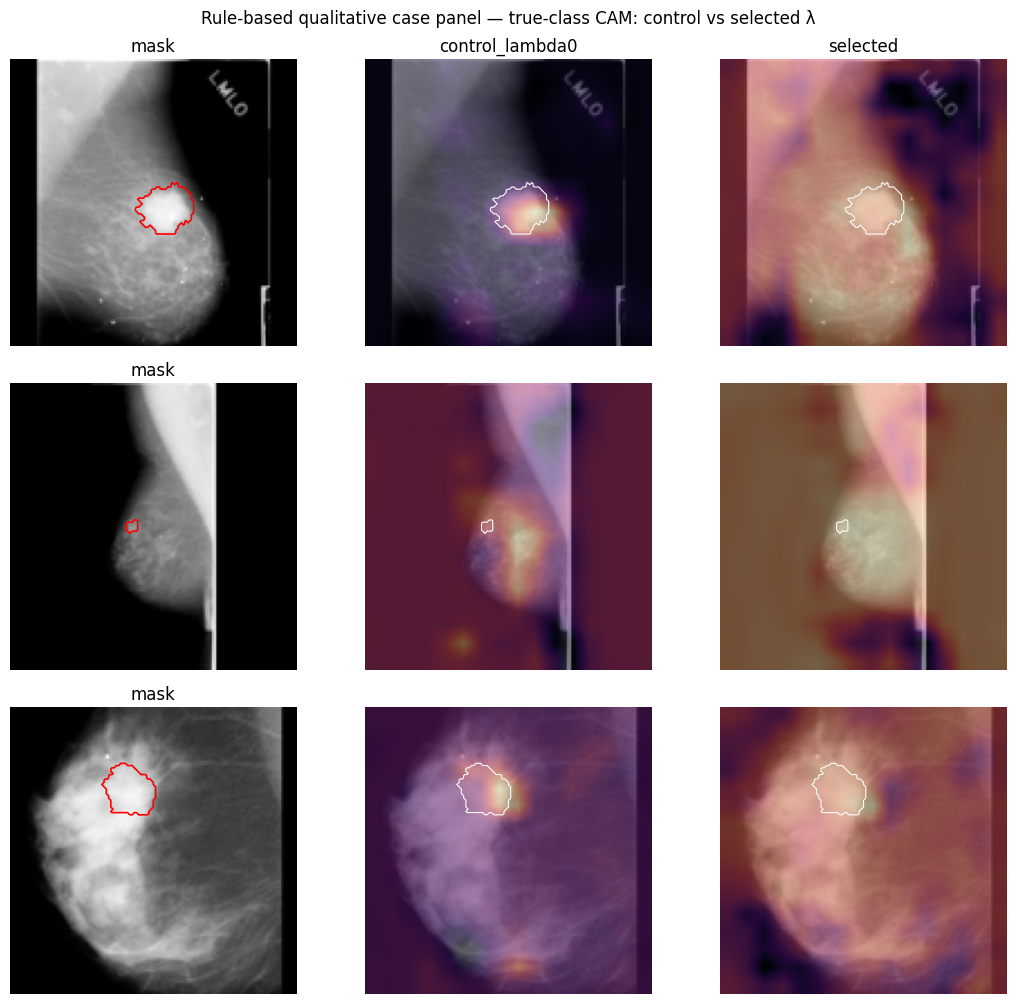

In [ ]:
sel_tp=final["selected"]["pred"].merge(test_df[["sample_id","label","has_malignant_mask"]],on="sample_id")
sel_tp=sel_tp[(sel_tp.label==1)&(sel_tp.has_malignant_mask)]
th=final["selected"]["threshold"]
picks=[]
correct=sel_tp[sel_tp.p_malignant>=th].sort_values("p_malignant",ascending=False)
wrong  =sel_tp[sel_tp.p_malignant< th].sort_values("p_malignant")
border =sel_tp.assign(d=(sel_tp.p_malignant-th).abs()).sort_values("d")
for pool in (correct,wrong,border):
    if len(pool): picks.append(pool.iloc[0].sample_id)
picks=list(dict.fromkeys(picks))

def overlay(gray,cam):
    g=np.array(gray,float)/255.; return np.clip(0.55*np.dstack([g,g,g])+0.45*matplotlib.colormaps["magma"](cam)[:,:,:3],0,1)
mods={t:ResNetCAM2().to(device) for t in ["control_lambda0","selected"]}
for t in mods: mods[t].load_state_dict(torch.load(models_by_lambda[final[t]["lambda"]],map_location=device)); mods[t].eval()
if picks:
    fig,ax=plt.subplots(len(picks),3,figsize=(11,3.4*len(picks)))
    if len(picks)==1: ax=ax[None,:]
    for r,sid in enumerate(picks):
        img=Image.open(ip(sid)).convert("L").resize((SUP_SIZE,SUP_SIZE))
        mask=np.array(Image.open(mp_(sid)).convert("L").resize((SUP_SIZE,SUP_SIZE),Image.NEAREST))>127
        ax[r,0].imshow(img,cmap="gray"); ax[r,0].contour(mask,levels=[.5],colors="red",linewidths=1.2); ax[r,0].set_title("mask"); ax[r,0].axis("off")
        t=torch.from_numpy(np.stack([np.array(Image.open(ip(sid)).convert("L"),np.float32)/255.]*3,0)); t=(t-MEAN)/STD
        for k,tag in enumerate(["control_lambda0","selected"]):
            cam=cam_map(mods[tag],t.float(),1)
            ax[r,k+1].imshow(overlay(img,cam)); ax[r,k+1].contour(mask,levels=[.5],colors="white",linewidths=.8)
            ax[r,k+1].set_title(f"{tag}" if r==0 else ""); ax[r,k+1].axis("off")
    plt.suptitle("Rule-based qualitative case panel — true-class CAM: control vs selected λ"); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"qualitative_panel.png"),dpi=200,bbox_inches="tight"); plt.show()

## 15. Central claim & honest framing

**Read classification and localisation together (from §11):**
- localisation ↑ (Pointing Game / pixel-AP), classification AUC paired-CI includes 0 → *more trustworthy
  at no accuracy cost* — defensible (pending CIs / external validation).
- classification AUC also ↑ (paired CI excludes 0, positive) → the lesion prior aided generalisation
  (plausible: V2 overfit).
- AUC ↓ significantly → report the accuracy/interpretability trade-off honestly.

**Why it's valid:** identical architecture + identical init + reused V2 split + deterministic per-λ
loaders → λ is the only variable. Two-class CAM supervises the **true-class** map against the
**true-class** ROI (benign masks used too); mixed-pathology images supervise only the malignant ROI.
λ selected on validation; the locked test set is scored once.

**Distinctive analyses included:** lesion-size stratification (§13 — your original small-lesion
hypothesis), prevalence-adjusted PPV/NPV (§12 — your interim objective), benign/malignant localisation
split, pixel-AP alongside pixel-AUC, reproducible (non-cherry-picked) qualitative panel.

**Optional later extensions (do NOT block the result):** multi-scale layer3+layer4 CAM; 3-seed
mean±std for the two final models; ConvNeXt repeat (point `cam_conv` at its final feature map);
predicted-class CAMs for decision explanation alongside these true-class localisation numbers.